In [1]:
%pip install ucimlrepo


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 

y= heart_disease.data.target.copy()
  
data = heart_disease.data.features.copy()
data.replace(to_replace='?', value=np.nan, inplace=True)
data=data.apply(pd.to_numeric, errors='coerce')
data = data.dropna()
data.fillna(data.mean(), inplace=True)

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(data)

In [64]:
print(X)



[[ 0.93618065  0.69109474 -2.24062879 ...  2.26414539 -0.72197605
   0.65587737]
 [ 1.3789285   0.69109474  0.87388018 ...  0.6437811   2.47842525
  -0.89422007]
 [ 1.3789285   0.69109474  0.87388018 ...  0.6437811   1.41162482
   1.17257652]
 ...
 [ 1.48961547  0.69109474  0.87388018 ...  0.6437811   1.41162482
   1.17257652]
 [ 0.27205887  0.69109474  0.87388018 ...  0.6437811   0.34482438
   1.17257652]
 [ 0.27205887 -1.44697961 -1.20245913 ...  0.6437811   0.34482438
  -0.89422007]]


In [66]:
print(y)

[[0]
 [2]
 [1]
 [0]
 [0]
 [0]
 [3]
 [0]
 [2]
 [1]
 [0]
 [0]
 [2]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [3]
 [4]
 [0]
 [0]
 [0]
 [0]
 [3]
 [0]
 [2]
 [1]
 [0]
 [0]
 [0]
 [3]
 [1]
 [3]
 [0]
 [4]
 [0]
 [0]
 [0]
 [1]
 [4]
 [0]
 [4]
 [0]
 [0]
 [0]
 [0]
 [2]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [2]
 [0]
 [1]
 [0]
 [2]
 [2]
 [1]
 [0]
 [2]
 [1]
 [0]
 [3]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [3]
 [0]
 [0]
 [0]
 [3]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [3]
 [0]
 [0]
 [0]
 [1]
 [2]
 [3]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [3]
 [0]
 [2]
 [1]
 [2]
 [3]
 [1]
 [1]
 [0]
 [2]
 [2]
 [0]
 [0]
 [0]
 [3]
 [2]
 [3]
 [4]
 [0]
 [3]
 [1]
 [0]
 [3]
 [3]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [4]
 [3]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [4]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [4]
 [3]
 [1]
 [1]
 [1]
 [2]
 [0]
 [0]
 [4]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [3]
 [0]
 [1]
 [0]
 [4]
 [1]
 [0]
 [1]
 [0]
 [0]
 [3]
 [2]
 [0]
 [0]
 [1]
 [0]
 [0]
 [2]
 [1]
 [2]
 [0]
 [3]
 [1]
 [2]
 [0]
 [3]
 [0]
 [0]
 [0]
 [1]


In [67]:
import numpy as np

X=np.array(X)
y=np.array(y)


In [68]:
class K_means:
    def __init__(self, k=2, max_iter=1000, tol=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X):
        self.centroids={}

        for i in range(self.k):
            self.centroids[i] = X[i]

        for i in range(self.max_iter):
            self.classification = {}
            for i in range(self.k):
                self.classification[i] = []
            
            for featureset in X:
                distances = [np.linalg.norm(featureset - self.centroids[centroid]) for centroid in self.centroids]
                classification = distances.index(min(distances))
                self.classification[classification].append(featureset)

            prev_centroids = dict(self.centroids)
            for classification in self.classification:
                self.centroids[classification] = np.average(self.classification[classification], axis=0)
                optimized = True

            for center in self.centroids:
                original = prev_centroids[center]
                current = self.centroids[center]
                if np.sum((current - original) / original * 100.0) > self.tol:
                    optimized = False

            if optimized:
                break

    def predict(self, X):
        distances = [np.linalg.norm(X - self.centroids[centroid]) for centroid in self.centroids]
        classification = distances.index(min(distances))
        return classification

In [69]:
clf = K_means()
clf.fit(X)

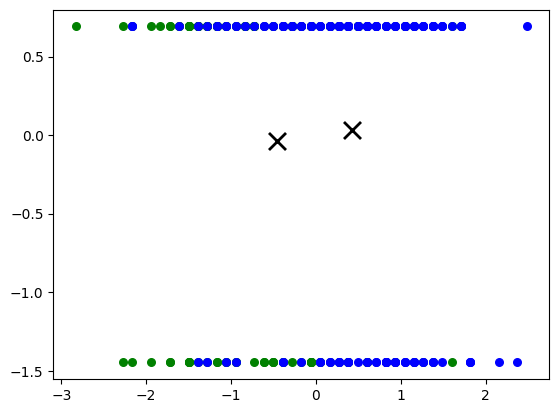

In [75]:
import matplotlib.pyplot as plt

for centroid in clf.centroids:
    plt.scatter(clf.centroids[centroid][0], clf.centroids[centroid][1], marker='x', color='k', s=150, linewidths=2)

for classification in clf.classification:
    color=colors[classification]
    for featureset in clf.classification[classification]:
        plt.scatter(featureset[0], featureset[1], color=color, s=30) 

plt.show()

In [76]:
correct=0
for i in range(len(X)):
    prediction = np.array(X[i].astype(float))
    prediction = prediction.reshape(-1,len(prediction))
    prediction = clf.predict(prediction)
    if prediction == y[i]:
        correct += 1

print(f'Accuracy: {correct/len(X)}')

Accuracy: 0.42424242424242425
